# 🔍 Fraud Detection - Decision Tree Classifier

Ce notebook couvre le pipeline complet :
1. **EDA** (Exploratory Data Analysis)
2. **Feature Engineering**
3. **Modélisation** avec DecisionTreeClassifier + Hyperparamétrage (GridSearchCV)
4. **Soumission** - Génération du fichier de prédictions

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries importees avec succes!")

Libraries importees avec succes!


## 1. Chargement des Données

In [2]:
# =============================================================================
# 1. CHARGEMENT DES DONNEES
# =============================================================================
df = pd.read_csv("Fraud Detection Dataset.csv")
print(f"Shape du dataset: {df.shape}")
print(f"\nColonnes:\n{list(df.columns)}")
print(f"\nTypes de donnees:\n{df.dtypes}")
print(f"\nPremieres lignes:\n{df.head()}")

Shape du dataset: (51000, 12)

Colonnes:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']

Types de donnees:
Transaction_ID                          str
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                        str
Time_of_Transaction                 float64
Device_Used                             str
Location                                str
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                          str
Fraudulent                            int64
dtype: object

Premieres lignes:
  Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0             T1     4174             1292.76   ATM Withdrawal   
1      

## 2. EDA - Analyse Exploratoire des Données

In [15]:
# =============================================================================
# 2.1 VALEURS MANQUANTES
# =============================================================================
print("--- Valeurs manquantes ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

--- Valeurs manquantes ---
                     Missing  Percentage
Transaction_Amount      2520    4.941176
Time_of_Transaction     2552    5.003922
Device_Used             2473    4.849020
Location                2547    4.994118
Payment_Method          2469    4.841176


In [4]:
# =============================================================================
# 2.2 STATISTIQUES DESCRIPTIVES
# =============================================================================
print("--- Statistiques numériques ---")
print(df.describe())

print("\n--- Statistiques catégorielles ---")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))

--- Statistiques numériques ---
            User_ID  Transaction_Amount  Time_of_Transaction  \
count  51000.000000        48480.000000         48448.000000   
mean    3005.110176         2996.249784            11.488400   
std     1153.121107         5043.932555             6.922954   
min     1000.000000            5.030000             0.000000   
25%     2007.000000         1270.552500             5.000000   
50%     2996.000000         2524.100000            12.000000   
75%     4006.000000         3787.240000            17.000000   
max     4999.000000        49997.800000            23.000000   

       Previous_Fraudulent_Transactions   Account_Age  \
count                      51000.000000  51000.000000   
mean                           1.995725     60.033902   
std                            1.415150     34.384131   
min                            0.000000      1.000000   
25%                            1.000000     30.000000   
50%                            2.000000     60.00

--- Distribution de Fraudulent ---
Fraudulent
0    48490
1     2510
Name: count, dtype: int64

Pourcentage de fraude: 4.92%


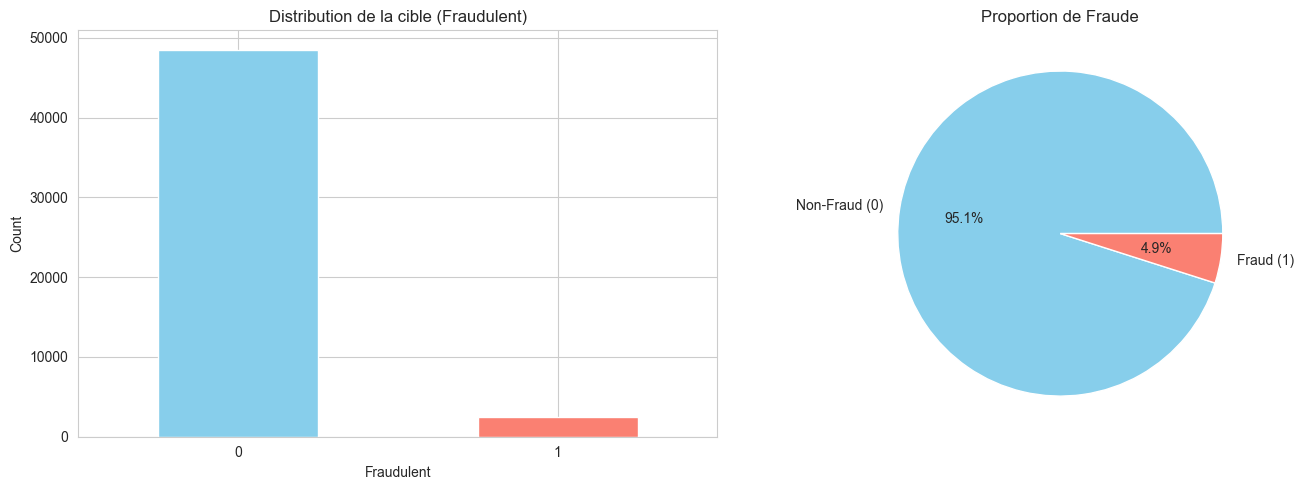

In [ ]:
# =============================================================================
# 2.3 DISTRIBUTION DE LA CIBLE (FRAUDULENT)
# =============================================================================
print("--- Distribution de Fraudulent ---")
target_counts = df['Fraudulent'].value_counts()
print(target_counts)
print(f"\nPourcentage de fraude: {target_counts.get(1, 0) / len(df) * 100:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribution de la cible (Fraudulent)')
axes[0].set_xlabel('Fraudulent')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                   colors=['skyblue', 'salmon'], labels=['Non-Fraud (0)', 'Fraud (1)'])
axes[1].set_title('Proportion de Fraude')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

--- Montant par fraude ---
              count         mean          std    min       25%      50%  \
Fraudulent                                                                
0           46095.0  2989.931309  5010.290069   5.03  1272.255  2524.39   
1            2385.0  3118.367245  5654.749402  14.31  1222.260  2516.01   

                75%      max  
Fraudulent                    
0           3789.59  49997.8  
1           3738.62  49997.8  


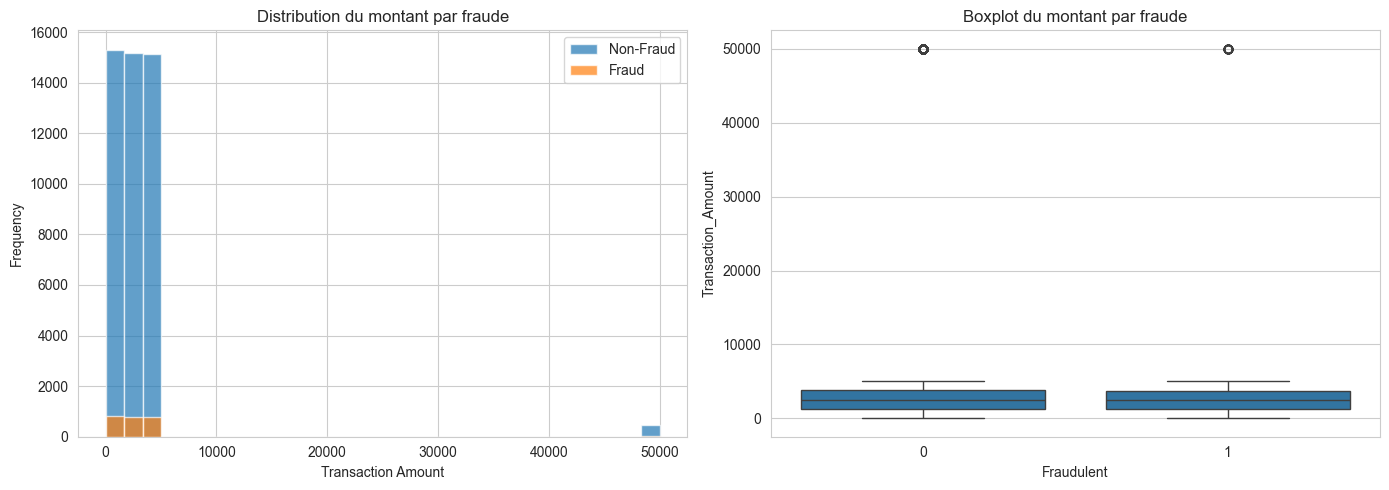

In [ ]:
# =============================================================================
# 2.4 MONTANT DE TRANSACTION PAR FRAUDE
# =============================================================================
print("--- Montant par fraude ---")
print(df.groupby('Fraudulent')['Transaction_Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[df['Fraudulent'] == 0]['Transaction_Amount'].hist(bins=30, ax=axes[0], alpha=0.7, label='Non-Fraud')
df[df['Fraudulent'] == 1]['Transaction_Amount'].hist(bins=30, ax=axes[0], alpha=0.7, label='Fraud')
axes[0].set_title('Distribution du montant par fraude')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x='Fraudulent', y='Transaction_Amount', data=df, ax=axes[1])
axes[1].set_title('Boxplot du montant par fraude')
plt.tight_layout()
plt.show()

--- Type de transaction vs Fraude ---
Fraudulent                0         1
Transaction_Type                     
ATM Withdrawal    95.346320  4.653680
Bank Transfer     95.192682  4.807318
Bill Payment      95.048356  4.951644
Online Purchase   94.808797  5.191203
POS Payment       94.993087  5.006913


<Figure size 1000x600 with 0 Axes>

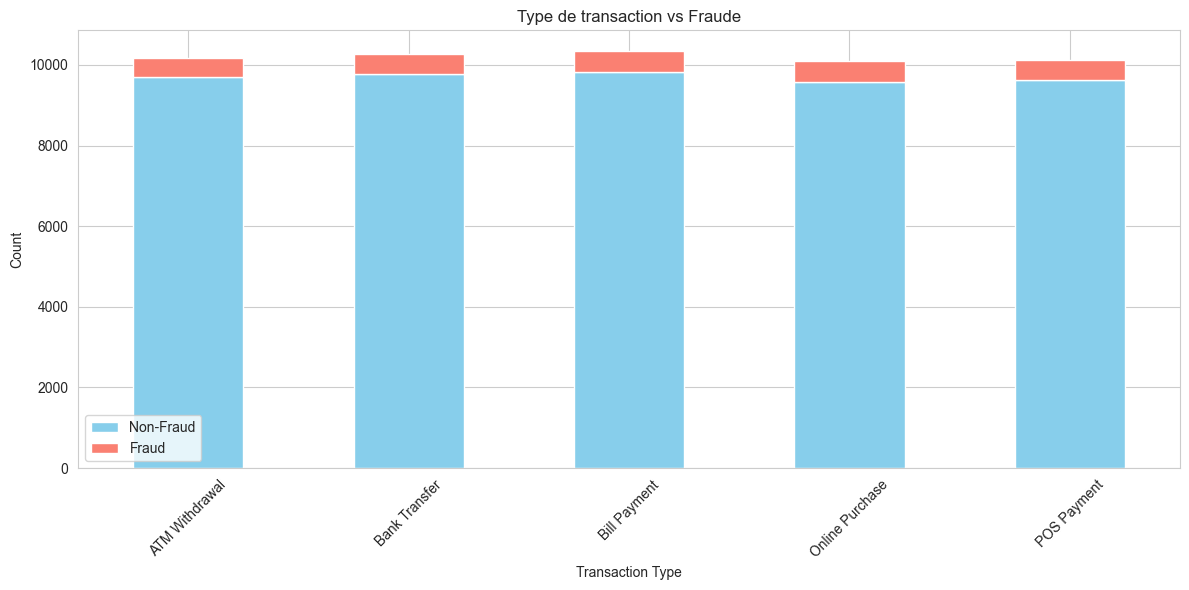

In [ ]:
# =============================================================================
# 2.5 TYPE DE TRANSACTION vs FRAUDE
# =============================================================================
print("--- Type de transaction vs Fraude ---")
tx_type_fraud = pd.crosstab(df['Transaction_Type'], df['Fraudulent'], normalize='index') * 100
print(tx_type_fraud)

plt.figure(figsize=(10, 6))
tx_type_counts = pd.crosstab(df['Transaction_Type'], df['Fraudulent'])
tx_type_counts.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Type de transaction vs Fraude')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(['Non-Fraud', 'Fraud'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- Appareil vs Fraude ---
Fraudulent              0         1
Device_Used                        
Desktop         95.264324  4.735676
Mobile          94.837966  5.162034
Tablet          95.323326  4.676674
Unknown Device  95.098039  4.901961


<Figure size 800x500 with 0 Axes>

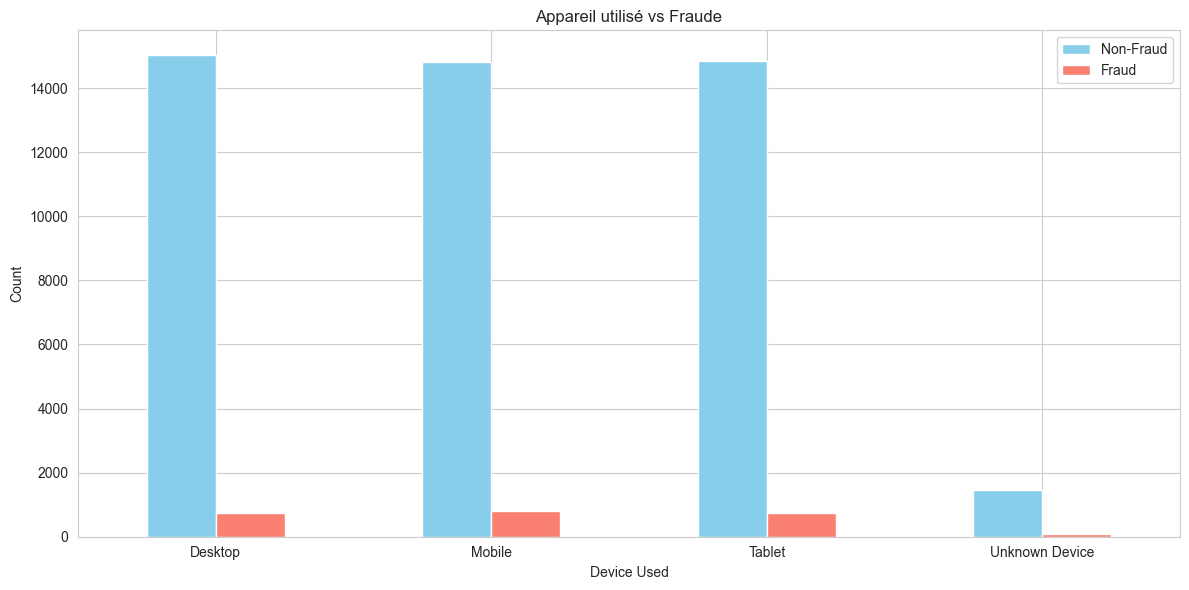

In [ ]:
# =============================================================================
# 2.6 APPAREIL vs FRAUDE
# =============================================================================
print("--- Appareil vs Fraude ---")
device_fraud = pd.crosstab(df['Device_Used'], df['Fraudulent'], normalize='index') * 100
print(device_fraud)

plt.figure(figsize=(8, 5))
device_counts = pd.crosstab(df['Device_Used'], df['Fraudulent'])
device_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Appareil utilisé vs Fraude')
plt.xlabel('Device Used')
plt.ylabel('Count')
plt.legend(['Non-Fraud', 'Fraud'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

--- Localisation vs Fraude ---
Fraudulent             0         1
Location                          
Boston         94.958530  5.041470
Chicago        94.498435  5.501565
Houston        95.324159  4.675841
Los Angeles    94.843646  5.156354
Miami          95.025872  4.974128
New York       95.253682  4.746318
San Francisco  95.037594  4.962406
Seattle        95.642202  4.357798


<Figure size 1000x500 with 0 Axes>

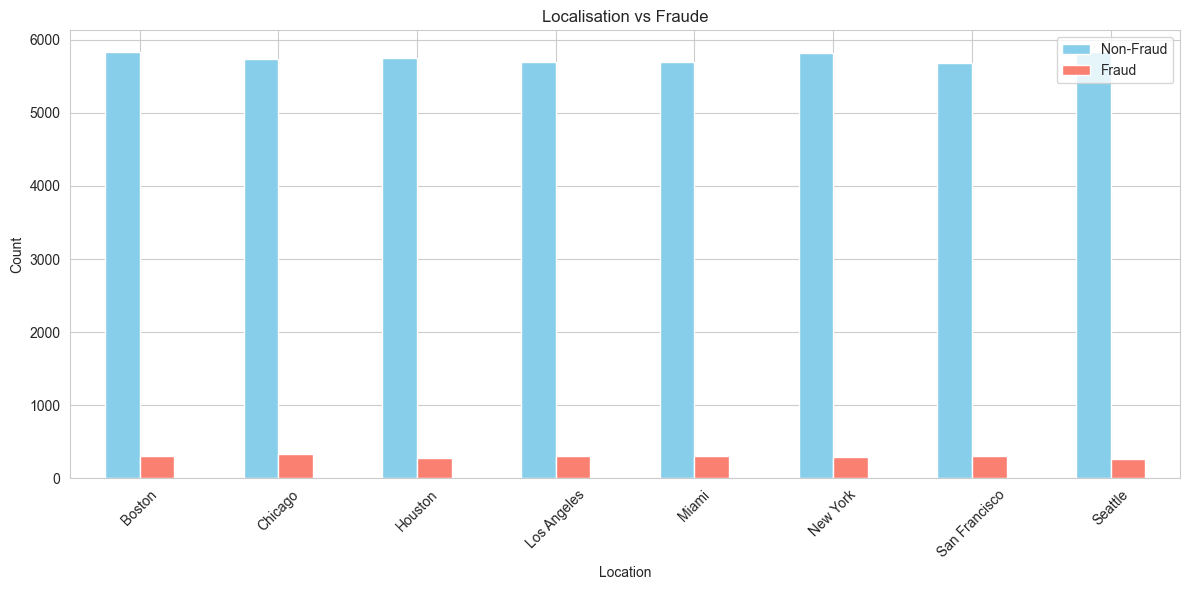

In [ ]:
# =============================================================================
# 2.7 LOCALISATION vs FRAUDE
# =============================================================================
print("--- Localisation vs Fraude ---")
loc_fraud = pd.crosstab(df['Location'], df['Fraudulent'], normalize='index') * 100
print(loc_fraud)

plt.figure(figsize=(10, 5))
loc_counts = pd.crosstab(df['Location'], df['Fraudulent'])
loc_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Localisation vs Fraude')
plt.xlabel('Location')
plt.ylabel('Count')
plt.legend(['Non-Fraud', 'Fraud'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- Méthode de paiement vs Fraude ---
Fraudulent              0         1
Payment_Method                     
Credit Card     95.071269  4.928731
Debit Card      95.153364  4.846636
Invalid Method  95.228758  4.771242
Net Banking     95.079719  4.920281
UPI             94.851518  5.148482


<Figure size 800x500 with 0 Axes>

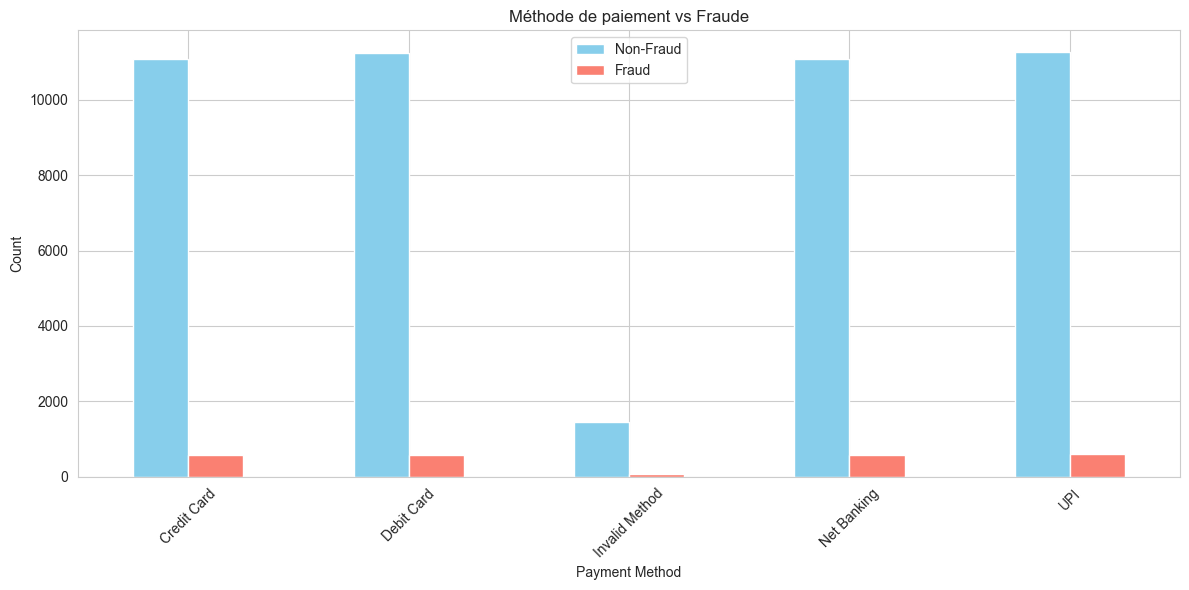

In [ ]:
# =============================================================================
# 2.8 MÉTHODE DE PAIEMENT vs FRAUDE
# =============================================================================
print("--- Méthode de paiement vs Fraude ---")
pay_fraud = pd.crosstab(df['Payment_Method'], df['Fraudulent'], normalize='index') * 100
print(pay_fraud)

plt.figure(figsize=(8, 5))
pay_counts = pd.crosstab(df['Payment_Method'], df['Fraudulent'])
pay_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Méthode de paiement vs Fraude')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.legend(['Non-Fraud', 'Fraud'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- Matrice de corrélation ---
                                   User_ID  Transaction_Amount  \
User_ID                           1.000000            0.001191   
Transaction_Amount                0.001191            1.000000   
Time_of_Transaction               0.001941           -0.007015   
Previous_Fraudulent_Transactions  0.002567           -0.001151   
Account_Age                       0.001749            0.003203   
Number_of_Transactions_Last_24H  -0.005847           -0.004538   
Fraudulent                        0.008046            0.005507   

                                  Time_of_Transaction  \
User_ID                                      0.001941   
Transaction_Amount                          -0.007015   
Time_of_Transaction                          1.000000   
Previous_Fraudulent_Transactions            -0.003411   
Account_Age                                 -0.003055   
Number_of_Transactions_Last_24H             -0.009274   
Fraudulent                               

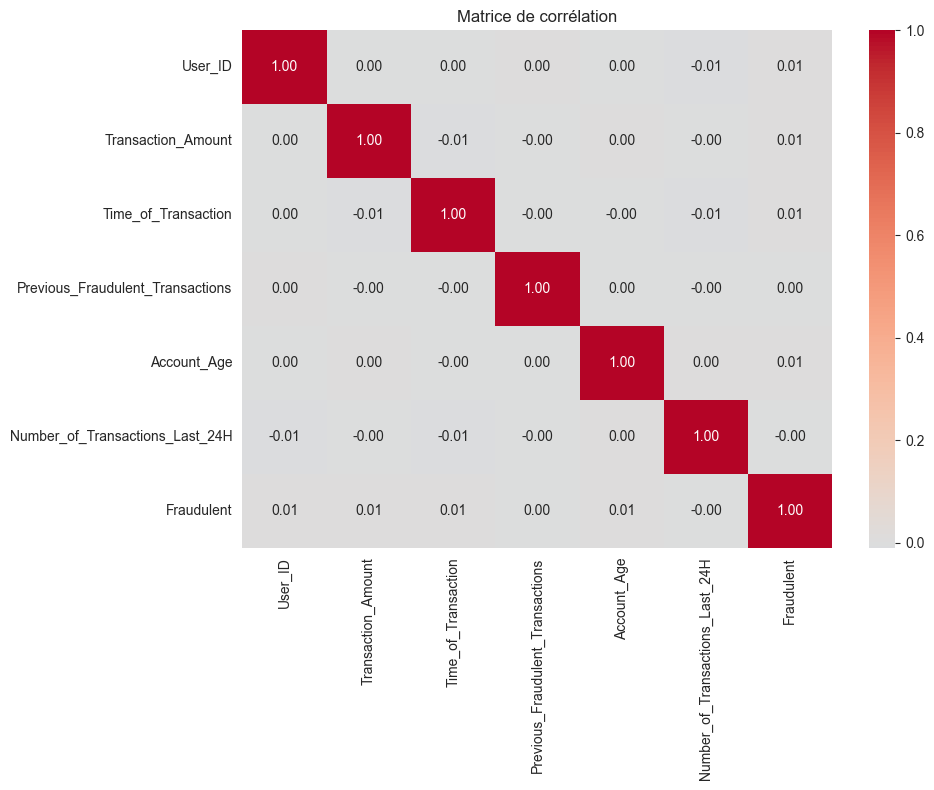

In [ ]:
# =============================================================================
# 2.9 MATRICE DE CORRÉLATION
# =============================================================================
print("--- Matrice de corrélation ---")
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

--- Heure de transaction vs Fraude ---
              count       mean       std  min  25%   50%   75%   max
Fraudulent                                                          
0           46072.0  11.477340  6.919978  0.0  5.0  12.0  17.0  23.0
1            2376.0  11.702862  6.978409  0.0  6.0  12.0  18.0  23.0


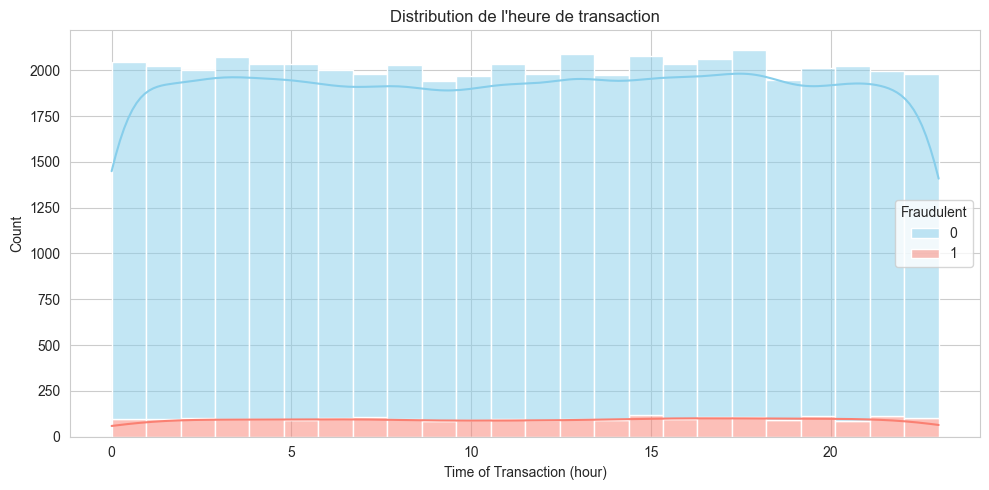

In [ ]:
# =============================================================================
# 2.10 HEURE DE TRANSACTION
# =============================================================================
print("--- Heure de transaction vs Fraude ---")
print(df.groupby('Fraudulent')['Time_of_Transaction'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Time_of_Transaction', hue='Fraudulent', bins=24, kde=True, 
             palette=['skyblue', 'salmon'], multiple='stack')
plt.title("Distribution de l'heure de transaction")
plt.xlabel('Time of Transaction (hour)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [28]:
# =============================================================================
# 3.1 TRAITEMENT DES VALEURS MANQUANTES
# =============================================================================
df_model = df.copy()

# Transaction_Amount: mediane par Transaction_Type
df_model['Transaction_Amount'] = df_model.groupby('Transaction_Type')['Transaction_Amount'].transform(
    lambda x: x.fillna(x.median())
)

# Time_of_Transaction: mediane globale
df_model['Time_of_Transaction'] = df_model['Time_of_Transaction'].fillna(
    df_model['Time_of_Transaction'].median()
)

# Categorielles: mode
df_model['Device_Used'] = df_model['Device_Used'].fillna(df_model['Device_Used'].mode()[0])
df_model['Location'] = df_model['Location'].fillna(df_model['Location'].mode()[0])
df_model['Payment_Method'] = df_model['Payment_Method'].fillna(df_model['Payment_Method'].mode()[0])

print("Valeurs manquantes apres traitement:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Valeurs manquantes apres traitement:
Series([], dtype: int64)


In [31]:
# =============================================================================
# 3.2 CREATION DE NOUVELLES FEATURES
# =============================================================================

# Montant par age du compte
df_model['Amount_per_Account_Age'] = df_model['Transaction_Amount'] / (df_model['Account_Age'] + 1)

# Flag montant eleve (au-dessus du 75e percentile)
amount_75 = df_model['Transaction_Amount'].quantile(0.75)
df_model['High_Amount'] = (df_model['Transaction_Amount'] > amount_75).astype(int)

# Ratio de frequence des transactions
df_model['Transaction_Frequency_Ratio'] = df_model['Number_of_Transactions_Last_24H'] / (df_model['Account_Age'] + 1)

# Categorie de l'heure
def categorize_time(hour):
    if pd.isna(hour):
        return 'Unknown'
    hour = float(hour)
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_model['Time_Category'] = df_model['Time_of_Transaction'].apply(categorize_time)

# Score de risque base sur les fraudes precedentes
df_model['Risk_Score'] = (df_model['Previous_Fraudulent_Transactions'] * 0.25).clip(0, 1)

# Compte recent (< 30 jours)
df_model['Is_New_Account'] = (df_model['Account_Age'] <= 30).astype(int)

# Haute activite
df_model['High_Activity'] = (df_model['Number_of_Transactions_Last_24H'] > 
                             df_model['Number_of_Transactions_Last_24H'].quantile(0.75)).astype(int)

# Interaction: fraudes precedentes * montant
df_model['Fraud_Amount_Interaction'] = df_model['Previous_Fraudulent_Transactions'] * df_model['Transaction_Amount']

print("Nouvelles features creees!")
print(f"Shape apres feature engineering: {df_model.shape}")
print(f"\nNouvelles colonnes: {[c for c in df_model.columns if c not in df.columns]}")

Nouvelles features creees!
Shape apres feature engineering: (51000, 20)

Nouvelles colonnes: ['Amount_per_Account_Age', 'High_Amount', 'Transaction_Frequency_Ratio', 'Time_Category', 'Risk_Score', 'Is_New_Account', 'High_Activity', 'Fraud_Amount_Interaction']


In [44]:
# =============================================================================
# 3.3 ENCODAGE DES VARIABLES CATEGORIELLES
# =============================================================================
le_dict = {}
categorical_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method', 'Time_Category']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f"{col}: {len(le.classes_)} classes encodees")

# Selection des features
feature_cols = [
    'Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions',
    'Account_Age', 'Number_of_Transactions_Last_24H',
    'Amount_per_Account_Age', 'High_Amount', 'Transaction_Frequency_Ratio',
    'Risk_Score', 'Is_New_Account', 'High_Activity', 'Fraud_Amount_Interaction',
    'Transaction_Type_encoded', 'Device_Used_encoded', 'Location_encoded',
    'Payment_Method_encoded', 'Time_Category_encoded'
]

X = df_model[feature_cols]
y = df_model['Fraudulent']

print(f"\nFeatures selectionnees ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  - {f}")

Transaction_Type: 5 classes encodees
Device_Used: 4 classes encodees
Location: 8 classes encodees
Payment_Method: 5 classes encodees
Time_Category: 4 classes encodees

Features selectionnees (17):
  - Transaction_Amount
  - Time_of_Transaction
  - Previous_Fraudulent_Transactions
  - Account_Age
  - Number_of_Transactions_Last_24H
  - Amount_per_Account_Age
  - High_Amount
  - Transaction_Frequency_Ratio
  - Risk_Score
  - Is_New_Account
  - High_Activity
  - Fraud_Amount_Interaction
  - Transaction_Type_encoded
  - Device_Used_encoded
  - Location_encoded
  - Payment_Method_encoded
  - Time_Category_encoded


## 4. Modélisation - DecisionTreeClassifier + Hyperparamétrage

In [45]:
# =============================================================================
# 4.1 TRAIN-TEST SPLIT
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train fraud ratio: {y_train.mean():.4f}")
print(f"Test fraud ratio: {y_test.mean():.4f}")

Train set: (40800, 17)
Test set: (10200, 17)
Train fraud ratio: 0.0492
Test fraud ratio: 0.0492


In [46]:
# =============================================================================
# 4.2 GRIDSEARCHCV - HYPERPARAMETRES (SIMPLIFIE)
# =============================================================================
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced', None]
}

print(f"Grid Search - Nombre de combinaisons: {np.prod([len(v) for v in param_grid.values()])}")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\nEntrainement en cours...")
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs hyperparametres:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMeilleur F1-score (CV): {grid_search.best_score_:.4f}")

Grid Search - Nombre de combinaisons: 48

Entrainement en cours...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Meilleurs hyperparametres:
  class_weight: balanced
  criterion: gini
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 2

Meilleur F1-score (CV): 0.0939


In [37]:
# =============================================================================
# 4.3 EVALUATION DU MODELE
# =============================================================================
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RESULTATS SUR LE TRAIN SET")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1]):.4f}")

print("\n" + "=" * 50)
print("RESULTATS SUR LE TEST SET")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT (TEST)")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=['Non-Fraud', 'Fraud']))

RESULTATS SUR LE TRAIN SET
Accuracy:  0.5312
Precision: 0.0568
Recall:    0.5463
F1-Score:  0.1029
ROC-AUC:   0.5549

RESULTATS SUR LE TEST SET
Accuracy:  0.5166
Precision: 0.0426
Recall:    0.4104
F1-Score:  0.0771
ROC-AUC:   0.4587

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

   Non-Fraud       0.94      0.52      0.67      9698
       Fraud       0.04      0.41      0.08       502

    accuracy                           0.52     10200
   macro avg       0.49      0.47      0.37     10200
weighted avg       0.90      0.52      0.64     10200



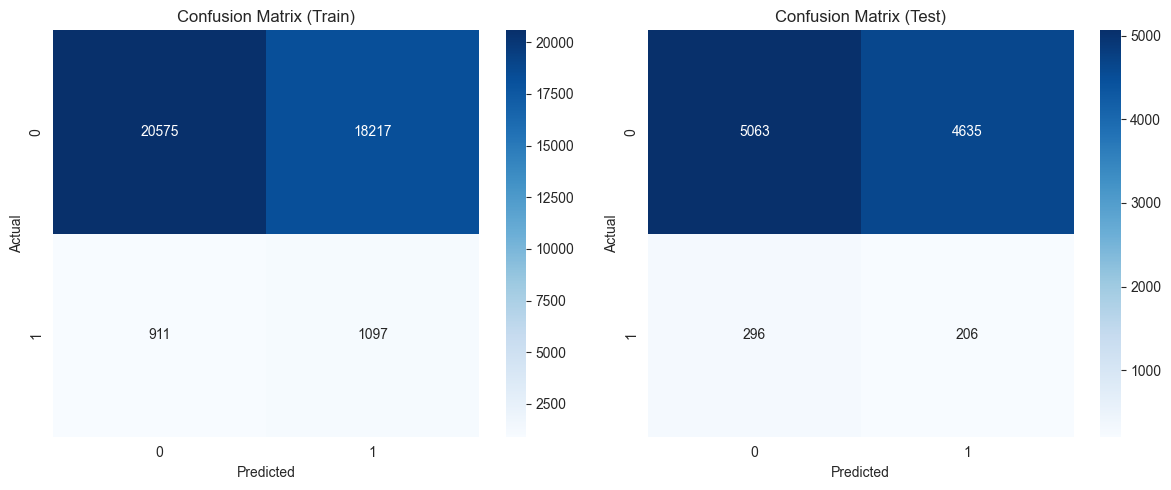

In [47]:
# =============================================================================
# 4.4 MATRICE DE CONFUSION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Train)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix (Test)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

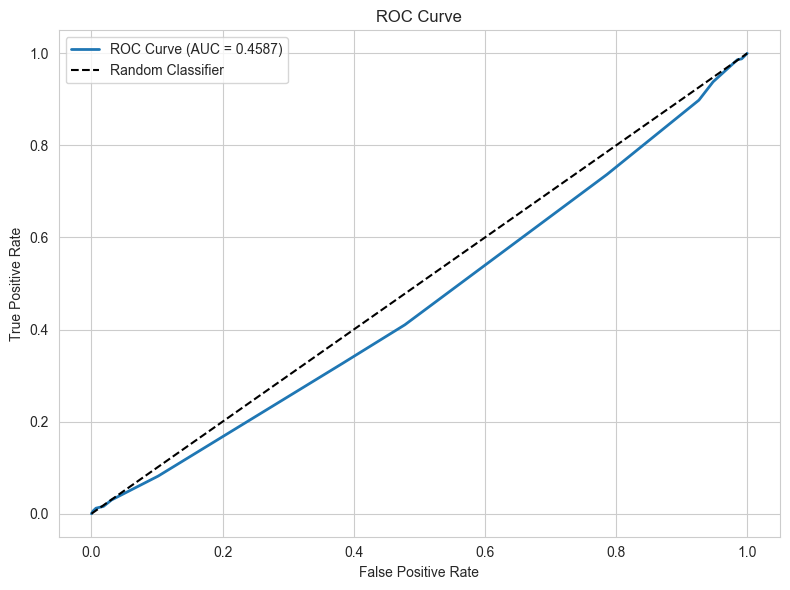

In [39]:
# =============================================================================
# 4.5 COURBE ROC
# =============================================================================
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_proba):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--- Importance des features ---
                             Feature  Importance
7        Transaction_Frequency_Ratio    0.230157
5             Amount_per_Account_Age    0.155140
1                Time_of_Transaction    0.124803
15            Payment_Method_encoded    0.123419
0                 Transaction_Amount    0.097434
11          Fraud_Amount_Interaction    0.081083
12          Transaction_Type_encoded    0.069528
3                        Account_Age    0.065550
14                  Location_encoded    0.052886
8                         Risk_Score    0.000000
6                        High_Amount    0.000000
2   Previous_Fraudulent_Transactions    0.000000
4    Number_of_Transactions_Last_24H    0.000000
9                     Is_New_Account    0.000000
10                     High_Activity    0.000000
13               Device_Used_encoded    0.000000
16             Time_Category_encoded    0.000000


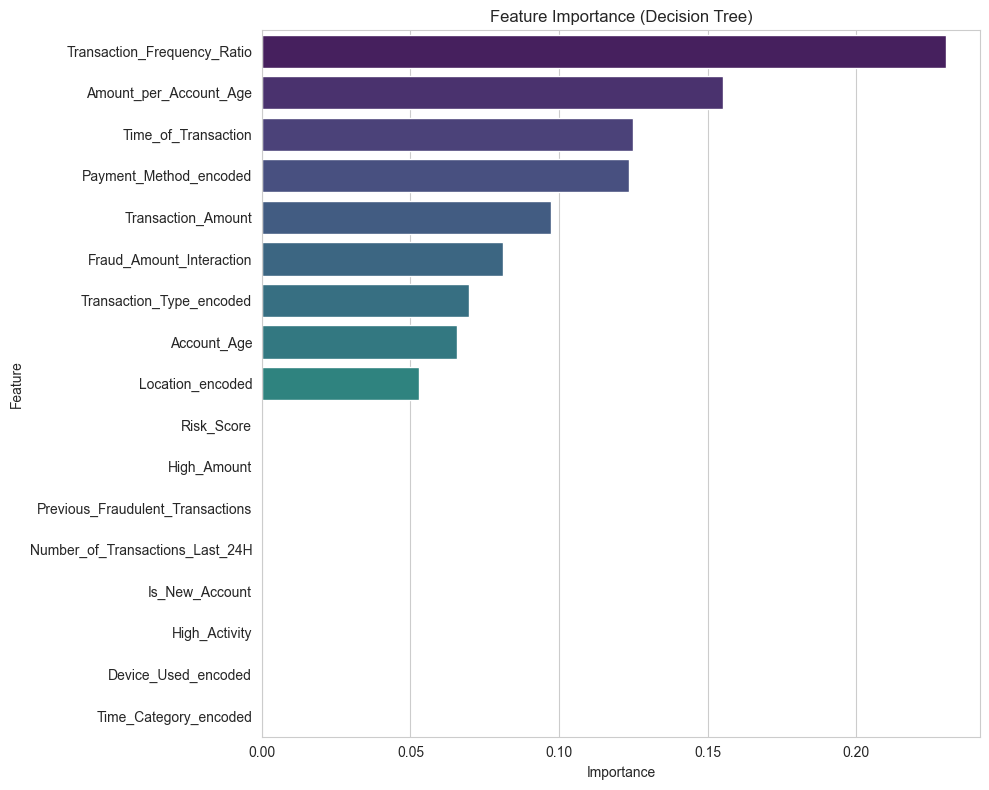

In [48]:
# =============================================================================
# 4.6 IMPORTANCE DES FEATURES
# =============================================================================
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("--- Importance des features ---")
print(feature_importance)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Decision Tree)')
plt.tight_layout()
plt.show()

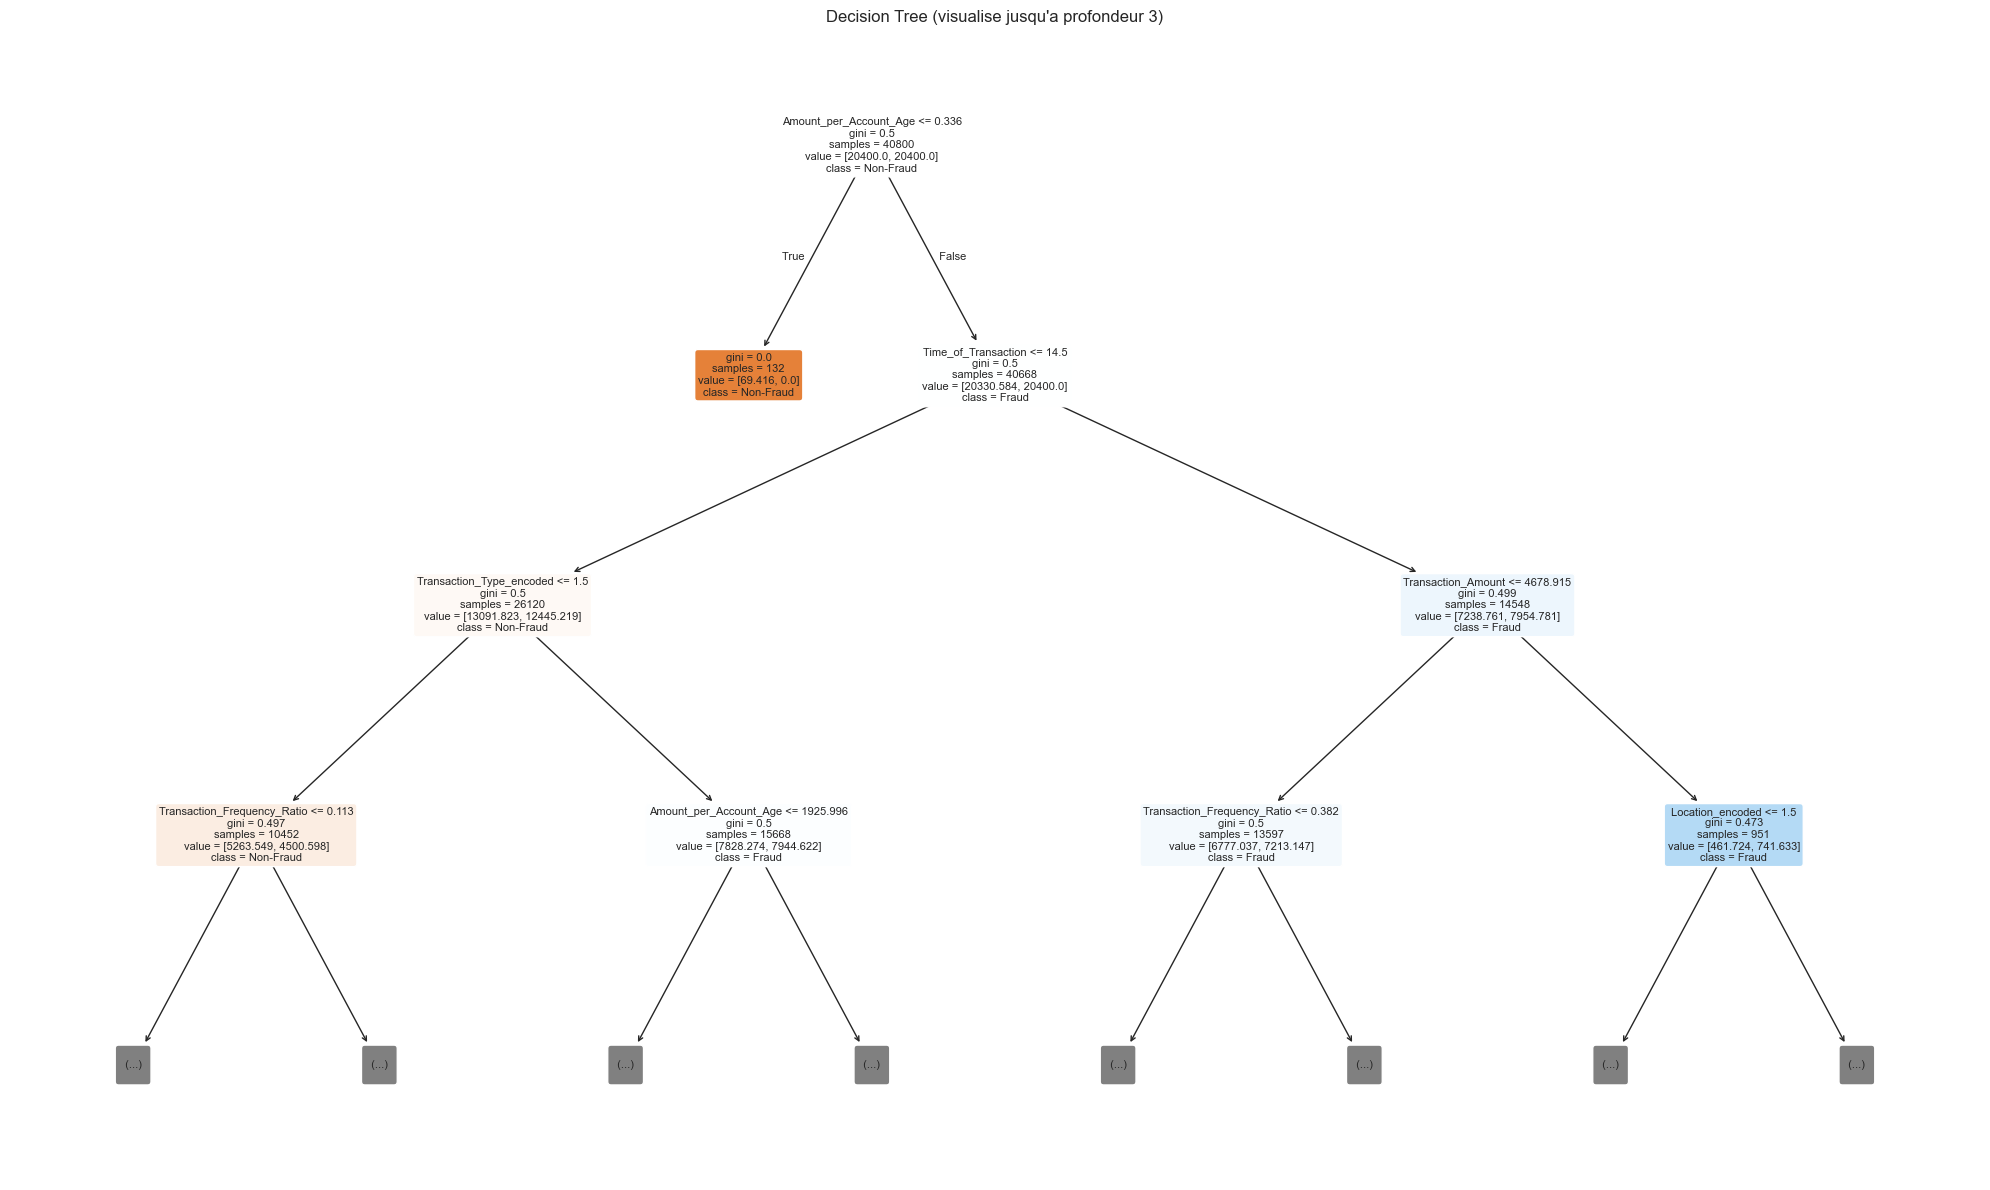

In [41]:
# =============================================================================
# 4.7 VISUALISATION DE L'ARBRE (profondeur limitée)
# =============================================================================
plt.figure(figsize=(20, 12))
plot_tree(best_model, feature_names=feature_cols, class_names=['Non-Fraud', 'Fraud'], 
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (visualise jusqu'a profondeur 3)")
plt.tight_layout()
plt.show()

## 5. Génération du Fichier de Soumission

In [42]:
# =============================================================================
# 5.1 PREDICTIONS SUR LE DATASET COMPLET
# =============================================================================
full_predictions = best_model.predict(X)
full_proba = best_model.predict_proba(X)[:, 1]

# Creation du DataFrame de soumission
submission = pd.DataFrame({
    'Transaction_ID': df_model['Transaction_ID'],
    'Fraudulent_Predicted': full_predictions,
    'Fraud_Probability': full_proba
})

# Sauvegarde
submission_path = "submission_predictions.csv"
submission.to_csv(submission_path, index=False)

print(f"Fichier de soumission sauvegarde: {submission_path}")
print(f"Shape: {submission.shape}")
print(f"\nApercu:")
print(submission.head(10))

print(f"\n--- Resume des predictions ---")
print(submission['Fraudulent_Predicted'].value_counts())
print(f"Taux de fraude predit: {submission['Fraudulent_Predicted'].mean():.4f}")

Fichier de soumission sauvegarde: submission_predictions.csv
Shape: (51000, 3)

Apercu:
  Transaction_ID  Fraudulent_Predicted  Fraud_Probability
0             T1                     1           0.528526
1             T2                     0           0.421988
2             T3                     1           0.521856
3             T4                     1           0.559463
4             T5                     1           0.528526
5             T6                     1           0.528526
6             T7                     1           0.548098
7             T8                     0           0.426377
8             T9                     1           0.521856
9            T10                     0           0.493951

--- Resume des predictions ---
Fraudulent_Predicted
0    26845
1    24155
Name: count, dtype: int64
Taux de fraude predit: 0.4736


In [43]:
# =============================================================================
# 5.2 RAPPORT DETAILLE
# =============================================================================
report = f"""
================================================================================
FRAUD DETECTION - RAPPORT DE MODELISATION
================================================================================
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. DATASET
   - Total samples: {len(df)}
   - Features: {len(feature_cols)}
   - Fraud rate: {y.mean():.4f}

2. FEATURE ENGINEERING
   - Missing values handled: imputation par mediane/mode
   - New features created: {len(df_model.columns) - len(df.columns)}
   - Categorical encoding: Label Encoding

3. MODEL
   - Algorithm: DecisionTreeClassifier
   - Hyperparameter tuning: GridSearchCV (3-fold Stratified CV)
   - Best parameters:
"""
for param, value in grid_search.best_params_.items():
    report += f"     * {param}: {value}\n"

report += f"""
4. PERFORMANCE (Test Set)
   - Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}
   - Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}
   - Recall:    {recall_score(y_test, y_test_pred, zero_division=0):.4f}
   - F1-Score:  {f1_score(y_test, y_test_pred, zero_division=0):.4f}
   - ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}

5. TOP 5 FEATURES IMPORTANTES
"""
for i, row in feature_importance.head(5).iterrows():
    report += f"   - {row['Feature']}: {row['Importance']:.4f}\n"

report += f"""
6. SUBMISSION
   - File: {submission_path}
   - Predicted frauds: {submission['Fraudulent_Predicted'].sum()}
   - Predicted non-frauds: {(submission['Fraudulent_Predicted'] == 0).sum()}

================================================================================
"""

report_path = "model_report.txt"
with open(report_path, 'w') as f:
    f.write(report)

print(f"Rapport detaille sauvegarde: {report_path}")
print(report)

Rapport detaille sauvegarde: model_report.txt

FRAUD DETECTION - RAPPORT DE MODELISATION
Date: 2026-04-27 15:19:56

1. DATASET
   - Total samples: 51000
   - Features: 17
   - Fraud rate: 0.0492

2. FEATURE ENGINEERING
   - Missing values handled: imputation par mediane/mode
   - New features created: 13
   - Categorical encoding: Label Encoding

3. MODEL
   - Algorithm: DecisionTreeClassifier
   - Hyperparameter tuning: GridSearchCV (3-fold Stratified CV)
   - Best parameters:
     * class_weight: balanced
     * criterion: gini
     * max_depth: 5
     * min_samples_leaf: 1
     * min_samples_split: 2

4. PERFORMANCE (Test Set)
   - Accuracy:  0.5166
   - Precision: 0.0426
   - Recall:    0.4104
   - F1-Score:  0.0771
   - ROC-AUC:   0.4587

5. TOP 5 FEATURES IMPORTANTES
   - Transaction_Frequency_Ratio: 0.2302
   - Amount_per_Account_Age: 0.1551
   - Time_of_Transaction: 0.1248
   - Payment_Method_encoded: 0.1234
   - Transaction_Amount: 0.0974

6. SUBMISSION
   - File: submission_p

## Pipeline Termine!

### Fichiers generes :
- `submission_predictions.csv` - Fichier de soumission avec predictions
- `model_report.txt` - Rapport detaille du modele
- `01_target_distribution.png` a `12_decision_tree.png` - Graphiques EDA et modele

### Resume du modele :
- **Algorithme** : DecisionTreeClassifier
- **Hyperparametrage** : GridSearchCV avec 3-fold Stratified CV
- **Metriques cles** : Accuracy, Precision, Recall, F1-Score, ROC-AUC